# The CEV model 
In this notebook, we introduce the **constant elasticity of volatility (CEV)** model, discuss its main assumptions, and show how it can be used to price options.

The CEV model is a modification of the Black–Scholes model in which the asset price follows the stochastic differential equation
$$
dS_t = \mu S_t\,dt + \sigma S_t^\beta\, dW_t,
$$
where $\beta \leq 1$ controls how the volatility depends on the asset price. In the special case $\beta = 1$, the CEV model matches the Black–Scholes model. Under the risk-neutral assumption, the equation becomes
$$
dS_t = r S_t\,dt + \sigma S_t^\beta\, dW_t,
$$
where $r$ is the risk-free interest rate.

Compared with the Black–Scholes model, the CEV model is harder to work with analytically, since it does not generally lead to a simple closed-form solution for option prices. For this reason, in this notebook we use the **binomial method** and **Monte Carlo** simulation to approximate option prices.

# The Binomial Method

Suppose that we want to price a call option with 
* Strike: K
* Time to expiration: T
* volatility: $\sigma$
* interest rate: $r$
* elasticity: $\beta$
* Number of steps: $N$

In contrast to the vanilla binomial method for Black-Scholes pricing, we cannot work with the asset price since its volatility is not constant anymore. This makes it more delicate to choose the states after $i$ time steps have passed and ensure that the tree recombines to ensure polynomial time complexity for the approximation algorithm instead of exponential. The solution is to make a convenient change of variable 
$$
X_t = S_t^{1 - \beta}.
$$
This change of variable transforms the stochastic differential equation into 
$$
dX_t
=
\bigg[(1-\beta)rX_t
-\frac12\beta(1-\beta)\sigma^2\frac{1}{X_t}\bigg]dt
+
(1-\beta)\sigma\,dW_t.
$$



As a result, the change in $X$ over a short period of time $\Delta t$ is approximately
$$
\Delta X \approx (1-\beta)\sigma \sqrt{\Delta t}.
$$

So, on the $X$ side, we can make the binary tree recombining by choosing the states as 
$$
X_{n,j} = X_{00} + j\Delta X,
$$
for all $0 \le n \le N$ where $X_{00} = S_0^{1-\beta}$ and
$$
\Delta X = (1-\beta)\sigma \sqrt{\Delta t}.
$$
We can now go back to the $S$ side by setting
$$
S_{n,j} = X_{n,j}^{\frac{1}{1-\beta}}
$$

The tree then looks like 

![title](states_diagram.jpeg)

To satisfy the risk free assumption we need to make sure that 
$$
S_{n,j} = e^{-r\Delta t}( p_{n,j}S_{n + 1, j} + (1 - p_{n,j})S_{n+1, j+ 1})
$$

Thus, 
$$
p_{n,j} = \frac{e^{r\Delta t}S_{n,j} - S_{n+1,j+1}}{S_{n+1,j} - S_{n+1,j+1}}. 
$$

# Working backwards to price European options 

We are now all set to start pricing options. We do this by starting with the last time step i.e. the expiration time. At this time a call is worth
$$
C_{N,i} = \max(S_{N,i} - K, 0),
$$
and a put option is worth
$$
P_{N, i} = \max(K - S_{N,i}, 0),
$$
for every $ 0 \le i \le N$. 

Working backwards, at time $n$ the price of the call option is 
$$
C_{n,i} = e^{-r\Delta t}\big( p_{n,i} C_{n+1, i} + (1-p_{n,i})C_{n+1, i+1}\big).
$$
Similarly, the put option is worth
$$
P_{n,i} = e^{-r\Delta t}\big( p_{n,i} P_{n+1, i} + (1-p_{n,i})P_{n+1, i+1}\big).
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson
from scipy.optimize import least_squares

import time

In [2]:
def CEV_binomial_european_call(S, K, T, sigma, r, N = 100, beta = 0.5): 
    """Brief description of the function.

    Args:
        S (numpy float vector): Spot prices
        K (numpy float vector): Strike Price
        T (float): Time to expiration in years
        r (float): yearly interset rate
        sigma (float): Yearly volatility 
        beta (float): Elasticity factor
        N (int): The number of steps to break the process into 
                       for binomial estimation of the price
                       

    Returns:
        float: Estimated price of the european call option with the given
               parameters. 

    Time complexity: O(N^2)
    """
    if(beta >= 1 or beta <= 0):
        print(f'invalid beta value: {beta}')
        return None
    
    S = np.array(S)
    K = np.array(K).reshape(-1,1)
    
    dt = T/N
    
    dx = sigma*(1-beta)*np.sqrt(dt)
    
    discount = np.exp(-r*dt)
    
    v = np.arange(0, -N - 1, -1)

    # Create an array of the delta X values
    deltas = np.array(v)
    for i in range(1, N + 1): 
        deltas = np.vstack((deltas, v + 2*i))
    
    
    l = len(S)

    # Go to the X space
    X = np.pow(S, 1 - beta)
    ones = np.ones((l, N + 1, N + 1))

    # Create an array of all the X states
    X_states = ones * (X[:,np.newaxis])[:, np.newaxis] + (deltas*dx)

    # Return to S states 
    S_states = np.pow(X_states, 1/(1 - beta))

    # Find the final possible values of the stock
    end_stock_prices = S_states[:, :, -1]

    # Find the transition probabilities p_{n,j}    
    transition_probs = (np.exp(r*dt)*S_states[:, :-1 :, :-1] - S_states[:, 1: :, 1: ]) / (S_states[:, :-1 :, 1:] - S_states[:, 1: :, 1: ])
    
    #initialize the values of the options at expiration date.
    values = np.maximum(end_stock_prices - K, 0)

    # work backwards inductively to predict the price at times T - (i + 1)*dt
    for i in range(0, N): 
        values = discount * ((1-transition_probs[:, :N-i  :, N - i - 1]) * values[:, 1:] + (transition_probs[:, :N-i :, N - i - 1]) * values[:, :-1])
    
    return values.flatten()

def CEV_binomial_european_put(S, K, T, sigma, r, N = 100, beta = 0.5): 
    """Brief description of the function.

    Args:
        S (numpy float vector): Spot prices
        K (numpy float vector): Strike Price
        T (float): Time to expiration in years
        r (float): yearly interset rate
        sigma (float): Yearly volatility 
        beta (float): Elasticity factor
        N (int): The number of steps to break the process into 
                       for binomial estimation of the price
                       

    Returns:
        float: Estimated price of the european call option with the given
               parameters. 

    Time complexity: O(N^2)
    """
    if(beta >= 1 or beta <= 0):
        print(f'invalid beta value: {beta}')
        return None
    
    S = np.array(S)
    K = np.array(K).reshape(-1,1)
    
    dt = T/N
    
    dx = sigma*(1-beta)*np.sqrt(dt)
    
    discount = np.exp(-r*dt)
    
    v = np.arange(0, -N - 1, -1)

    # Create an array of the delta X values
    deltas = np.array(v)
    for i in range(1, N + 1): 
        deltas = np.vstack((deltas, v + 2*i))
    
    
    l = len(S)

    # Go to the X space
    X = np.pow(S, 1 - beta)
    ones = np.ones((l, N + 1, N + 1))

    # Create an array of all the X states
    X_states = ones * (X[:,np.newaxis])[:, np.newaxis] + (deltas*dx)

    # Return to S states 
    S_states = np.pow(X_states, 1/(1 - beta))

    # Find the final possible values of the stock
    end_stock_prices = S_states[:, :, -1]

    # Find the transition probabilities p_{n,j}    
    transition_probs = (np.exp(r*dt)*S_states[:, :-1 :, :-1] - S_states[:, 1: :, 1: ]) / (S_states[:, :-1 :, 1:] - S_states[:, 1: :, 1: ])
    
    #initialize the values of the options at expiration date.
    values = np.maximum(K - end_stock_prices, 0)

    # # work backwards inductively to predict the price at times T - (i + 1)*dt
    for i in range(0, N): 
        values = discount * ((1-transition_probs[:, :N-i  :, N - i - 1]) * values[:, 1:] + (transition_probs[:, :N-i :, N - i - 1]) * values[:, :-1])
    
    return values.flatten()




# Monte Carlo simulation of the CEV model

As in the Black–Scholes model, the option price under the SEV model can also be approximated using Monte Carlo simulation. The following script performs the simulation.

In [3]:
def Monte_Carlo_european_call(S, K, T, sigma, r, N = 100, n_sims = 100, beta = 0.5): 
    """Brief description of the function.

    Args:
        S (numpy float vector): Spot prices
        K (numpy float vector): Strike Price
        T (float): Time to expiration in years
        sigma (float): Yearly volatility 
        r (float): yearly interset rate
        N (int): The number of steps to break the process into 
                       for binomial estimation of the price
        n_sims (int): The number of simulations
        beta (float): Elasticity factor
                       
    Returns:
        float: Estimated price of the european call option with the given
               parameters. 

    Time complexity: O(N * n_sims)
    """
    dt = T/N
    noise = np.random.normal(size = (n_sims, N))
    prices = np.ones(n_sims)*S
    for i in range(0, N): 
        prices = prices*(1 + r*dt) + sigma*np.sqrt(dt)*(np.pow(prices, beta)*noise[:, i])

    returns = np.exp(-r*T)*np.maximum(prices - K, 0)
    error = np.std(returns)/np.sqrt(n_sims)
    return np.mean(returns), error

def Monte_Carlo_european_put(S, K, T, sigma, r, N = 100, n_sims = 100, beta = 0.5): 
    
    """Brief description of the function.

    Args:
        S (numpy float vector): Spot prices
        K (numpy float vector): Strike Price
        T (float): Time to expiration in years
        sigma (float): Yearly volatility 
        r (float): yearly interset rate
        N (int): The number of steps to break the process into 
                       for binomial estimation of the price
        n_sims (int): The number of simulations
        beta (float): Elasticity factor
                       
    Returns:
        float: Estimated price of the european call option with the given
               parameters. 

    Time complexity: O(N * n_sims)
    """
    
    dt = T/N
    noise = np.random.normal(size = (n_sims, N))
    prices = np.ones(n_sims)*S
    for i in range(0, N): 
        prices = prices*(1 + r*dt) + sigma*np.sqrt(dt)*(np.pow(prices, beta)*noise[:, i])

    returns = np.exp(-r*T)*np.maximum(K - prices, 0)
    error = np.std(returns)/np.sqrt(n_sims)
    return np.mean(returns), error
    

Let's compare some of the values we find with the binomial method and Monte Carlo simulation. 

In [8]:
num_sims = 25000
S0 = 20
elasticity = 0.75
rate = 0.03
time = 1
vol = 0.3
num_steps = 1000
strikes = np.linspace(0.75*S0, 1.25*S0, num = 10)

print("Computing call option prices via monte carlo and the binomial method.")
print(f"Current price: {S0}")
print(f"Strike prices between: {strikes[0]}-{strikes[-1]}")
print(f"Volatility: {100*vol}%")
print(f"Time to expiration: {time*252} days")
print(f"beta: {elasticity}")
print(' ')
print('---'*30)
print(' ')

for strike in strikes: 
    binomial_price = CEV_binomial_european_call(S = [S0], K = [strike], T = time, sigma = vol, r = rate, N = num_steps, beta = elasticity)
    monte_carlo_price = Monte_Carlo_european_call(S = S0, K = strike, T = time, sigma = vol, r = rate, N = num_steps, n_sims = num_sims, beta = elasticity)
    print(f"Call binomial price with strike {strike} is:    {binomial_price}")
    print(f"Call Monte Carlo price with {num_sims} simulations is: {monte_carlo_price[0]}")
    print(f"Std error for Monte Carlo price with strike {strike} is: {monte_carlo_price[1]}")
    print(' ')
    print('---'*30)
    print(' ')

print(' ')
print('---'*30)
print(' ')
print("Computing put option prices via monte carlo and the binomial method.")
print(f"Current price: {S0}")
print(f"Strike prices between: {strikes[0]}-{strikes[-1]}")
print(f"Volatility: {100*vol}%")
print(f"Time to expiration: {time*252} days")
print(f"beta: {elasticity}")
print(' ')
print('---'*30)
print(' ')

for strike in strikes: 
    binomial_price = CEV_binomial_european_put(S = [S0], K = [strike], T = time, sigma = vol, r = rate, N = num_steps, beta = elasticity)
    monte_carlo_price = Monte_Carlo_european_put(S = S0, K = strike, T = time, sigma = vol, r = rate, N = num_steps, n_sims = num_sims, beta = elasticity)
    print(f"Put binomial price with strike {strike} is:    {binomial_price}")
    print(f"Put Monte Carlo price with {num_sims} simulations is: {monte_carlo_price[0]}")
    print(f"Std error for Monte Carlo price with strike {strike} is: {monte_carlo_price[1]}")
    print(' ')
    print('---'*30)
    print(' ')


Computing call option prices via monte carlo and the binomial method.
Current price: 20
Strike prices between: 15.0-25.0
Volatility: 30.0%
Time to expiration: 252 days
beta: 0.75
 
------------------------------------------------------------------------------------------
 
Call binomial price with strike 15.0 is:    [5.45694956]
Call Monte Carlo price with 25000 simulations is: 5.473064069634256
Std error for Monte Carlo price with strike 15.0 is: 0.01778013971114491
 
------------------------------------------------------------------------------------------
 
Call binomial price with strike 16.11111111111111 is:    [4.41331484]
Call Monte Carlo price with 25000 simulations is: 4.41717262390366
Std error for Monte Carlo price with strike 16.11111111111111 is: 0.017349362504558867
 
------------------------------------------------------------------------------------------
 
Call binomial price with strike 17.22222222222222 is:    [3.42248238]
Call Monte Carlo price with 25000 simulation

# Convergence of the binomial method

Let's see how fast the binomial method converges.

In [9]:

for num_steps in range(50, 1800, 200): 
    price = CEV_binomial_european_call(S = [20], K = [20], T = 1, sigma = 0.2, r = 0.03, N = num_steps, beta = 0.7)
    print(f'The price of the call option is {price} when we use {num_steps} steps')

for num_steps in range(50, 1800, 200): 
    price = CEV_binomial_european_put(S = [20], K = [20], T = 1, sigma = 0.2, r = 0.03, N = num_steps, beta = 0.7)
    print(f'The price of the put option is {price} when we use {num_steps} steps')
    


The price of the call option is [0.97494459] when we use 50 steps
The price of the call option is [0.97765208] when we use 250 steps
The price of the call option is [0.9779536] when we use 450 steps
The price of the call option is [0.97806961] when we use 650 steps
The price of the call option is [0.97813103] when we use 850 steps
The price of the call option is [0.97816906] when we use 1050 steps
The price of the call option is [0.97819492] when we use 1250 steps
The price of the call option is [0.97821365] when we use 1450 steps
The price of the call option is [0.97822783] when we use 1650 steps
The price of the put option is [0.38385526] when we use 50 steps
The price of the put option is [0.38656275] when we use 250 steps
The price of the put option is [0.38686428] when we use 450 steps
The price of the put option is [0.38698028] when we use 650 steps
The price of the put option is [0.38704171] when we use 850 steps
The price of the put option is [0.38707973] when we use 1050 steps

It looks like after around 1500 time steps, the price converges to within <0.01% error. 

In [10]:
# BS call, put, implied volatility functions copied and pasted from the course's GitHub page. 

def bs_call(S,K,sigma,t,r):
    '''

    Inputs:
    S(float): spot price
    K(float): strike price
    sigma(float): volatility
    t(float): time to expiration
    r(float): risk-free interest rate

    Output:
    Black-Scholes Price of Call Option
    
    '''
    d1 = (np.log(S/K)+(r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    call_price = S*norm.cdf(d1)-np.exp(-r*t)*K*norm.cdf(d2)

    return call_price


def bs_call_iv_vectorized(
    market_prices, 
    spots,
    strikes,
    ttes,
    r, 
    sigma0 = .2,
    max_iter = 100, 
    tol = 1e-8,
    vega_floor = 1e-6, 
    sigma_lo0 = .05, 
    sigma_hi0 = 8):

    #lengths of market_prices, spots, strikes, ttes are all the same

    data_length = len(market_prices)


    sigmas = np.full(data_length, sigma0, dtype = 'float')
    sigmas_lo = np.full(data_length, sigma_lo0, dtype = 'float')
    sigmas_hi = np.full(data_length, sigma_hi0, dtype = 'float')
    converged = np.zeros(data_length, dtype = bool)
    counts = np.zeros(data_length, dtype = int)


    lower = spots - np.exp(-r*ttes)*strikes
    upper = spots

    valid = (market_prices > lower) & (market_prices < upper)

    sigmas[~valid] = np.nan


    for _ in range(max_iter):

        active = (valid) & (~converged)

        if not np.any(active):
            break

        active_indexes = np.where(active)[0]


        
        market_prices_a = market_prices[active_indexes]
        spots_a = spots[active_indexes]
        strikes_a = strikes[active_indexes]
        sigmas_a = sigmas[active_indexes]
        ttes_a = ttes[active_indexes]



        bs_prices = bs_call(spots_a, strikes_a, sigmas_a, ttes_a, r)
    

        errors = -market_prices_a + bs_prices
        
        
        
        just_converged = np.abs(errors)<tol
    
    
        converged[active_indexes[just_converged]] = True



        active = (valid) & (~converged)

        active_indexes = np.where(active)[0]


        
        market_prices_a = market_prices[active_indexes]
        spots_a = spots[active_indexes]
        strikes_a = strikes[active_indexes]
        sigmas_a = sigmas[active_indexes]
        ttes_a = ttes[active_indexes]


        bs_prices = bs_call(spots_a, strikes_a, sigmas_a, ttes_a, r)

        errors= -market_prices_a + bs_prices
        


        new_lows = errors < 0
        new_highs = errors > 0

        sigmas_lo[active_indexes] = np.where(new_lows, sigmas_a, sigmas_lo[active_indexes])
        sigmas_hi[active_indexes] = np.where(new_highs, sigmas_a, sigmas_hi[active_indexes])



        vegas = bs_vega(spots_a, strikes_a, sigmas_a, ttes_a, r)

        sigmas_newton = sigmas_a - errors/np.maximum(vegas, vega_floor)

        sigmas_mid = (sigmas_lo[active_indexes] + sigmas_hi[active_indexes])*.5

        bad_newtons = (vegas < vega_floor) | (sigmas_newton < sigmas_lo[active_indexes]) | (sigmas_newton>sigmas_hi[active_indexes])


        sigmas[active_indexes] = np.where(bad_newtons, sigmas_mid, sigmas_newton)
        

    sigmas[~converged] = np.nan


    return sigmas, converged


def bs_vega(S,K,sigma,t,r):
    '''
    Inputs:
    S(float): spot price
    K(float): strike price
    sigma(float): volatility
    t(float): time to expiration
    r(float): risk-free interest rate

    Output:
    Black-Scholes Gamma of Call and Put Options
    '''

    d1 = (np.log(S/K) + (r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))

    return S*np.sqrt(t)*norm.pdf(d1)
    
def bs_call_iv(market_price,S0,K,t,r, max_iter = 100, tol = 1e-8):
    sigma = .2
    sigma_lo = .001
    sigma_hi = 5

    def f(sigma):
        return bs_call(S0,K,sigma,t,r) - market_price


    vega_floor = 1e-6

    
    for _ in range(max_iter):
        err = f(sigma)

        if abs(err)<tol:
            return sigma
        
        if err < 0:
            sigma_lo = sigma
        else:
            sigma_hi = sigma

        vega = bs_vega(S0,K,sigma,t,r)

        if vega < vega_floor:
            sigma_newton = np.nan

        else:
            sigma_newton = sigma - f(sigma)/vega

        if np.isfinite(sigma_newton) and sigma_lo < sigma_newton < sigma_hi:
            sigma = sigma_newton

        else:
            sigma = (0.5)*(sigma_lo + sigma_hi)


    return np.nan


# BS call, put, implied volatility functions copied and pasted from the course's GitHub page. 


# Implied volatility for the CEV model
Let's look at the implied volatilities for call options priced via the CEV model. 

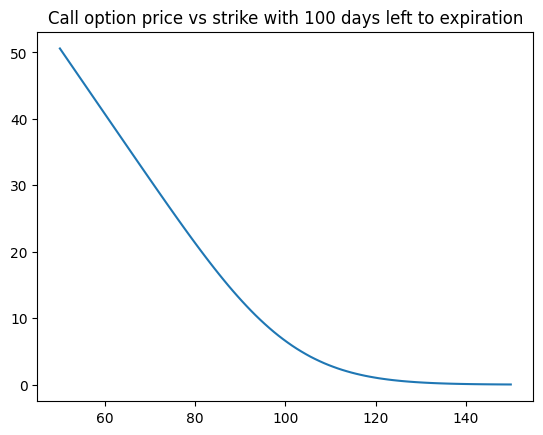

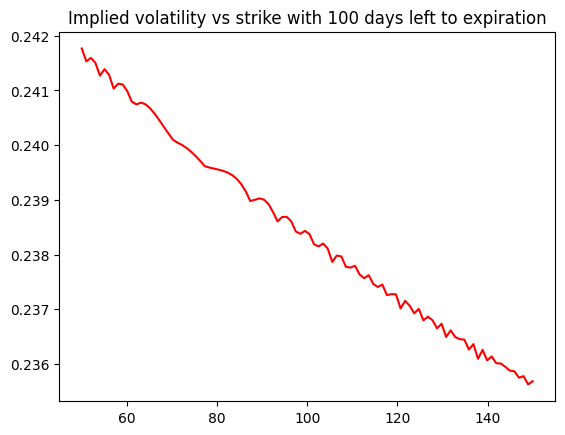

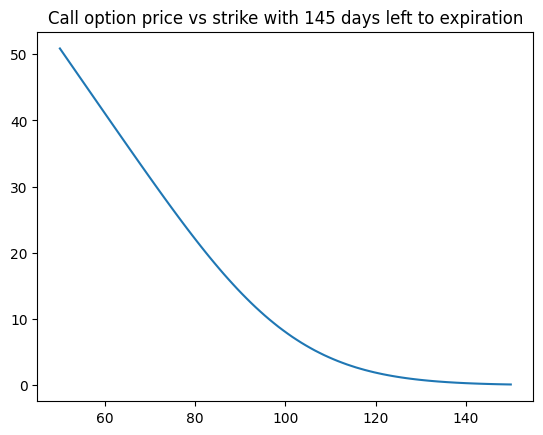

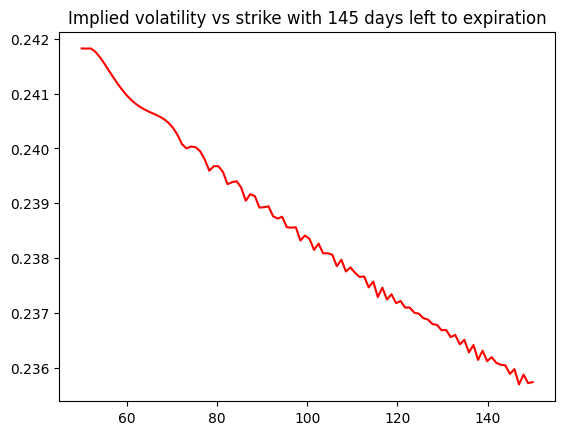

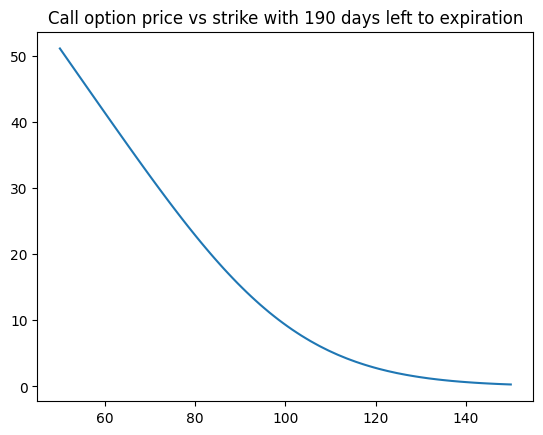

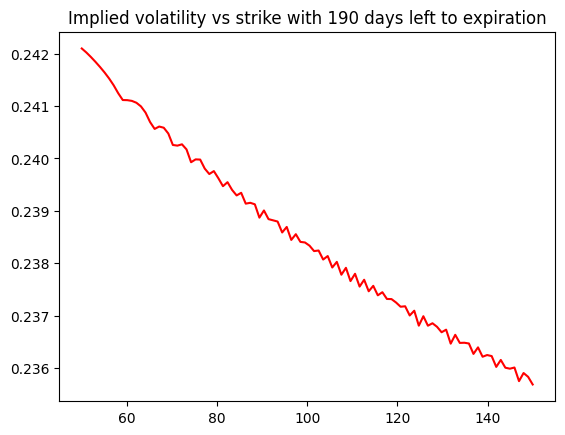

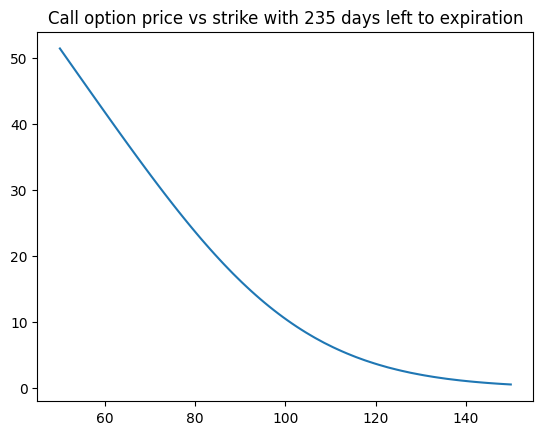

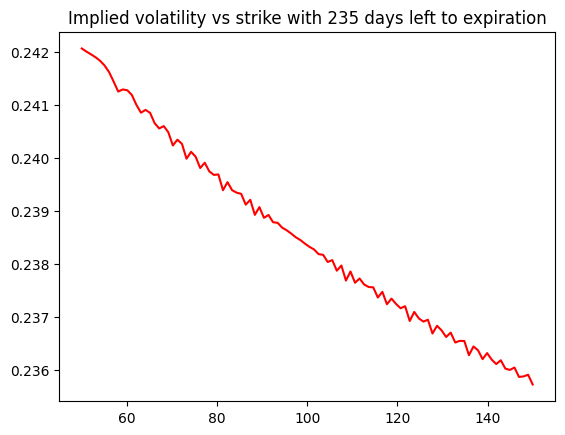

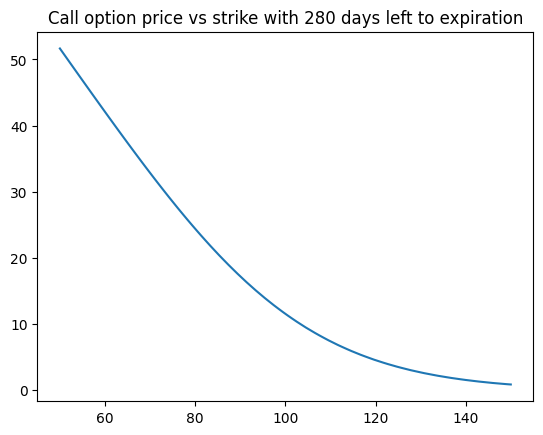

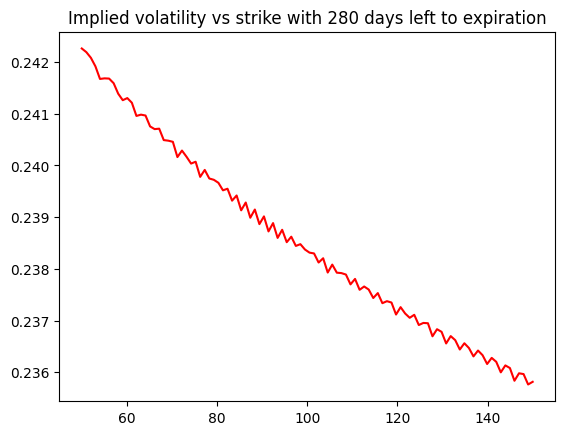

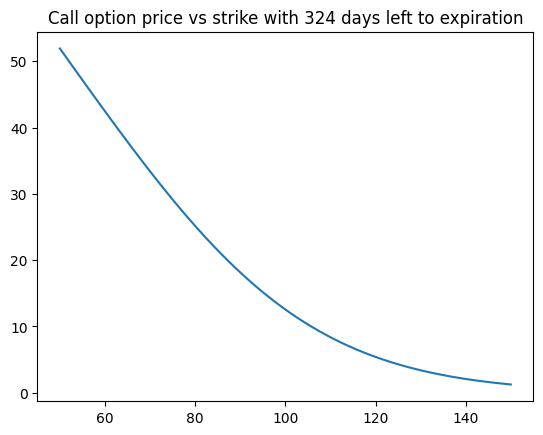

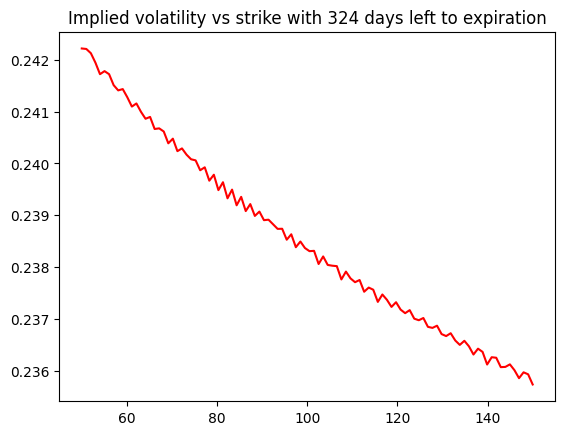

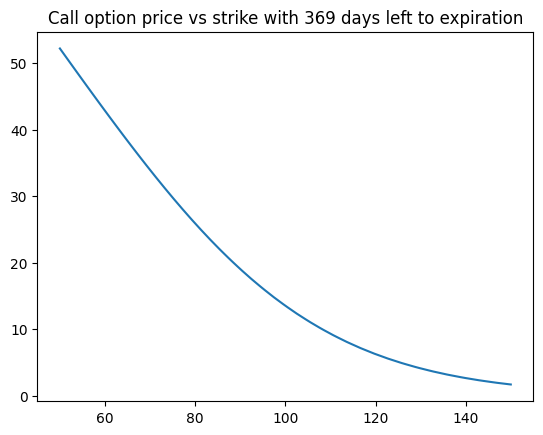

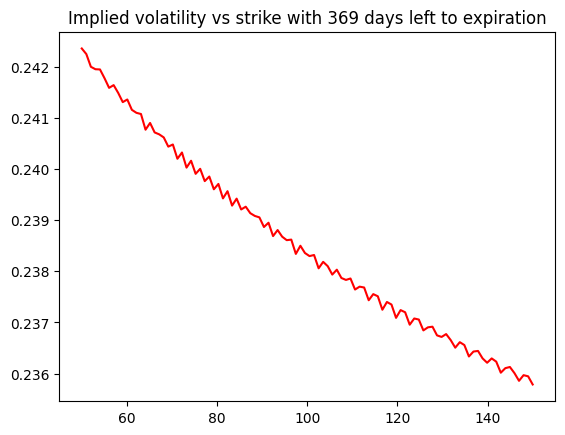

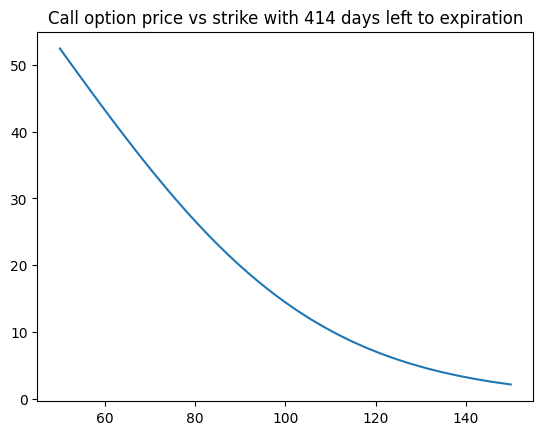

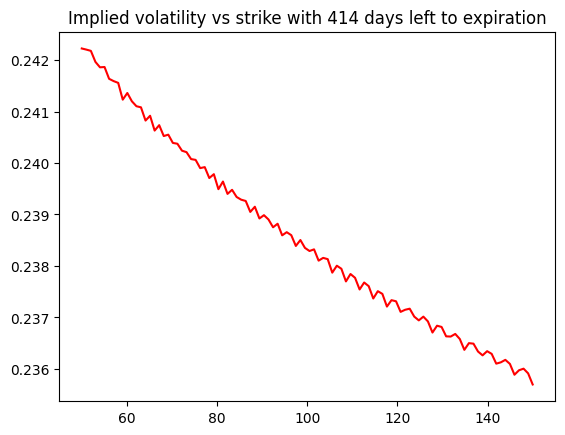

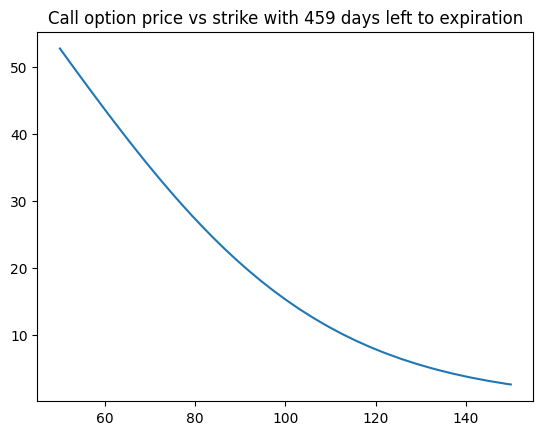

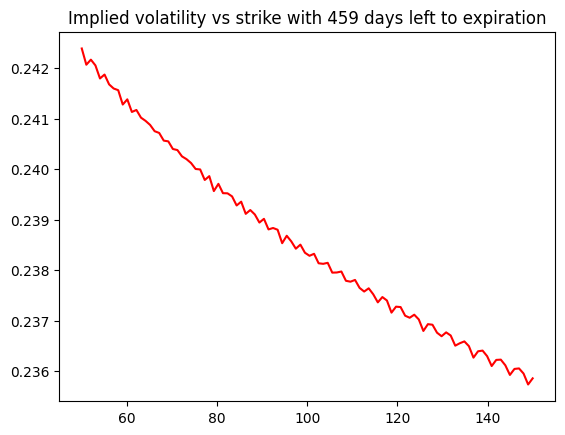

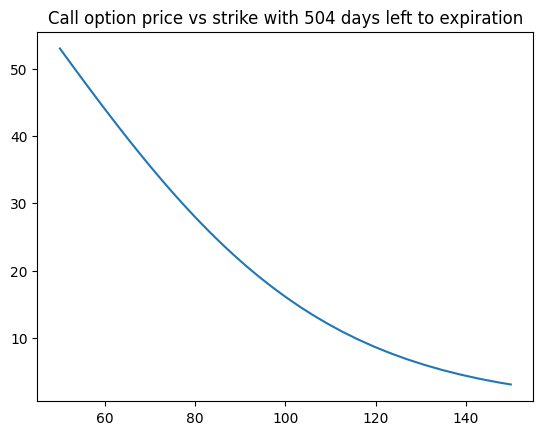

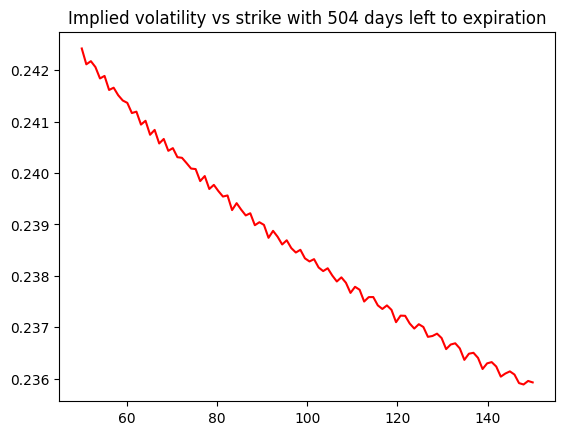

In [12]:
S0 = 100
sigma = 0.3
beta = 0.95
r = 0.03
num_times = 10 
num_increments = 100
num_steps = 500

spots = np.ones(num_increments)*S0
strikes = np.linspace(S0/2,1.5*S0, num = num_increments)

TTEs = np.linspace(0.4, 2, num = num_times)

for t in TTEs:
    prices = CEV_binomial_european_call(S = spots, K = strikes, T = t, sigma = sigma, r = r, N = num_steps, beta = beta)

    IVs = []
    for i in range(0, num_increments): 
        IVs.append(bs_call_iv(market_price = prices[i] ,S0 = S0 , K = strikes[i],t = t,r = r, max_iter = 5000))
    plt.plot(strikes, prices)
    plt.title(f'Call option price vs strike with {int(t*252)} days left to expiration')
    plt.show()
    plt.plot(strikes, np.array(IVs), color = 'red')
    plt.title(f'Implied volatility vs strike with {int(t*252)} days left to expiration')
    plt.savefig('figs/CEV-model/IVs/IV-vs-strike-tte:' + str(int(t*252)) + '.jpg')
    plt.show()


First note that, the fluctutations are due to the numerical approximation of the implied volatility and also of the binomial method. As can be seen from the graphs, the implied volatility is a strictly decreasing function of the strike. This is not surprising given that the rate of change of the stock in the CEV model decreases relative to a geometric brownian motion and thus the CEV model is much less likely to reach high prices in comparison to the Black-Scholes model. 